## Setup

We import the required libraries and define global parameters.

In [1]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import coint

TRADING_DAYS_PER_YEAR = 252
DEFAULT_DAILY_RF = 0.04 / TRADING_DAYS_PER_YEAR  # Approx. 4% annual risk-free rate


## Usefull functions:

In [2]:
#Transform Z score into trading position (1=long,-1=short, else 0)
def generate_signal(z_score: np.ndarray | pd.Series,
                    threshold_long: float,
                    threshold_short: float) -> np.ndarray:
    z = np.asarray(z_score, dtype=float)
    return np.where(z <= threshold_long, 1,
                    np.where(z >= threshold_short, -1, 0))

#Sharpe ratio
def _annualized_sharpe(returns: pd.Series, rf: float = DEFAULT_DAILY_RF) -> float:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return np.nan

    excess = r - rf
    sigma = excess.std(ddof=1)
    if pd.isna(sigma) or sigma == 0:
        return np.nan
    return float(np.sqrt(TRADING_DAYS_PER_YEAR) * excess.mean() / sigma)

#Sortino ratio: It is a sharpe-like ratio but which does only take into account the market movements where we are loosing money. So it's quite better.
def _annualized_sortino(returns: pd.Series, rf: float = DEFAULT_DAILY_RF) -> float:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return np.nan

    excess = r - rf

    # downside only
    downside = excess[excess < 0]

    if downside.empty:
        return np.nan

    downside_std = downside.std(ddof=1)
    if pd.isna(downside_std) or downside_std == 0:
        return np.nan

    return float(np.sqrt(TRADING_DAYS_PER_YEAR) * excess.mean() / downside_std)

#Total return (composed interest)
def _cumulative_return(returns: pd.Series) -> float:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return np.nan
    return float((1.0 + r).prod() - 1.0)

## 1. Data loading & preprocessing

We load all price series (coal + sector assets), clean them and align dates.

The goal is to obtain consistent time series before building pairs.

In [3]:
def load_price_file(path: str) -> pd.Series:
    suffix = path.split(".")[-1].lower()
    df = None

    if suffix == "csv":
        df = pd.read_csv(path)

    elif suffix in ["xls", "xlsx"]:
        for engine in [None, "openpyxl", "xlrd"]:
            try:
                df = pd.read_excel(path) if engine is None else pd.read_excel(path, engine=engine)
                break
            except Exception:
                pass

        if df is None:
            for sep in [",", ";", "\t"]:
                try:
                    df = pd.read_csv(path, sep=sep)
                    if df.shape[1] >= 2:
                        break
                except Exception:
                    pass
    else:
        raise ValueError(f"Unsupported file format: {path}")

    if df is None:
        raise ValueError(f"Could not read file: {path}")

    df.columns = [str(c).lower().strip() for c in df.columns]

    if "date" not in df.columns:
        raise ValueError(f"No 'date' column found in {path}. Columns are: {list(df.columns)}")

    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).copy().set_index("date")

    possible_cols = ["close", "adj close", "price", "last"]
    price_col = next((c for c in possible_cols if c in df.columns), None)

    if price_col is None:
        raise ValueError(f"No price column found in {path}. Columns are: {list(df.columns)}")

    s = df[price_col].astype(str).str.replace(",", "", regex=False).str.strip()
    s = pd.to_numeric(s, errors="coerce").dropna().sort_index()

    if s.empty:
        raise ValueError(f"No valid price data found in {path}")

    return s



# 1) STOCKS
stock_prices = pd.DataFrame({
    "AMR": load_price_file("coal_data/individual_universe/AMR_daily_5y.csv"),
    "ARLP": load_price_file("coal_data/individual_universe/ARLP_daily_5y.csv"),
    "BHP": load_price_file("coal_data/individual_universe/BHP_daily_5y.csv"),
    "BTU": load_price_file("coal_data/individual_universe/BTU_daily_5y.csv"),
    "HNRG": load_price_file("coal_data/individual_universe/HNRG_daily_5y.csv"),
    "NC": load_price_file("coal_data/individual_universe/NC_daily_5y.csv"),
    "NRP": load_price_file("coal_data/individual_universe/NRP_daily_5y.csv"),
    "RIO": load_price_file("coal_data/individual_universe/RIO_daily_5y.csv"),
    "TECK": load_price_file("coal_data/individual_universe/TECK_daily_5y.csv"),
    "WHC": load_price_file("coal_data/individual_universe/WHC_AU_daily_5y.csv"),
    "YAL": load_price_file("coal_data/individual_universe/YAL_AU_daily_5y.csv"),
})


# 2) SECTOR PROXIES
sector_prices = pd.DataFrame({
    "GNR": load_price_file("coal_data/sector_proxies/GNR_daily_5y.csv"),
    "IXC": load_price_file("coal_data/sector_proxies/IXC_daily_5y.csv"),
    "XLE": load_price_file("coal_data/sector_proxies/XLE_daily_5y.csv"),
})


# 3) ANCHOR (COAL Futures)

coal = load_price_file(
    "coal_data/the_primary_anchor/Newcastle Coal Futures Historical Data.csv.xls"
)

coal = coal.rename("COAL")

print(stock_prices.shape)
print(sector_prices.shape)
print(coal.shape)

stock_prices.head()

(1255, 11)
(1255, 3)
(1312,)


,AMR,ARLP,BHP,BTU,HNRG,NC,NRP,RIO,TECK,WHC,YAL
date,,,,,,,,,,,
2021-03-08,15.3814,5.11393,63.7220,3.72,1.73,20.9707,15.4399,70.0063,20.6350,1.705,2.45
2021-03-09,15.7457,5.11393,63.5871,3.90,1.93,20.6360,15.7768,68.7634,20.3423,1.745,2.38
2021-03-10,14.8251,5.17579,61.3507,3.86,2.01,20.8563,15.6617,67.3281,20.8087,1.675,2.37
2021-03-11,15.6595,5.21130,62.3013,3.74,2.03,20.9235,15.8834,69.2513,22.2107,1.690,2.33
2021-03-12,14.8731,5.17579,62.7040,3.77,2.00,20.7408,15.9139,68.2180,22.0737,1.660,2.34


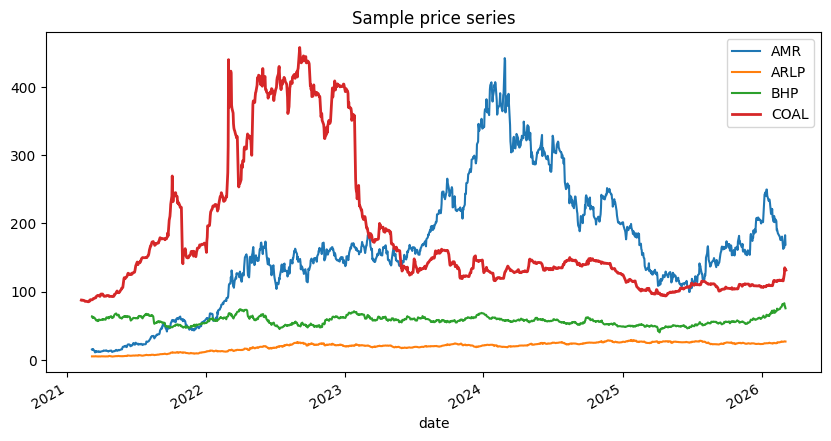

In [4]:
plt.figure(figsize=(10,5))
for name, s in list(stock_prices.items())[:3]:
    s.plot(label=name)

coal.plot(label="COAL", linewidth=2)

plt.legend()
plt.title("Sample price series")
plt.show()

## 2. Building pairs vs coal

We construct pairs between each asset and coal.

We work with log-prices to ensure consistency for statistical tests.

In [5]:
def prepare_pair_series(
    s1: pd.Series,
    s2: pd.Series,
    name1: str | None = None,
    name2: str | None = None
) -> pd.DataFrame:
    """
    Align two price series on common dates, clean them, and return log-prices.
    """
    df = pd.concat([s1, s2], axis=1, join="inner").copy()

    col1 = name1 if name1 is not None else (s1.name if s1.name is not None else "asset_1")
    col2 = name2 if name2 is not None else (s2.name if s2.name is not None else "asset_2")
    df.columns = [col1, col2]

    df = df.sort_index()
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # Keep only positive prices for log: It is only a security measure
    df = df[(df[col1] > 0) & (df[col2] > 0)]

    # Remove duplicated dates if any: same
    df = df[~df.index.duplicated(keep="first")]

    return np.log(df)

test on BTU:

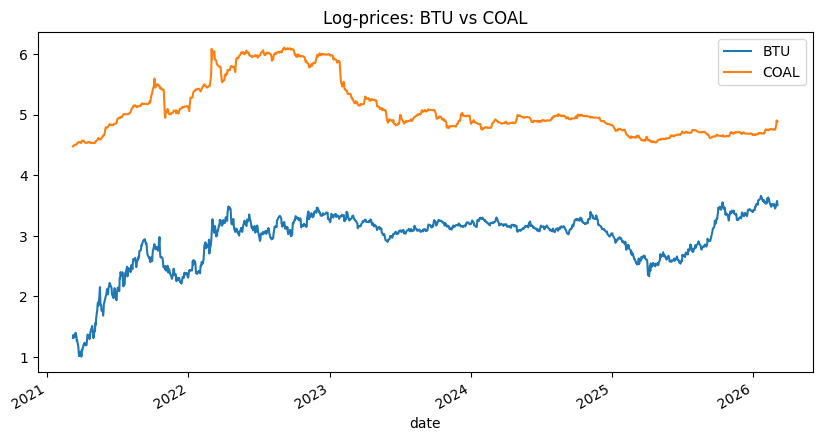

(1255, 2)


,BTU,COAL
date,,
2021-03-08,1.313724,4.477337
2021-03-09,1.360977,4.483003
2021-03-10,1.350667,4.488636
2021-03-11,1.319086,4.488636
2021-03-12,1.327075,4.499810


In [6]:
pair_log = prepare_pair_series(stock_prices["BTU"], coal, "BTU", "COAL")
pair_log.plot(figsize=(10, 5), title="Log-prices: BTU vs COAL")
plt.show()
print(pair_log.shape)
pair_log.head()

In [7]:
# Universe = stocks + sector proxies
full_universe = pd.concat([stock_prices, sector_prices], axis=1)
full_universe = full_universe.loc[:, ~full_universe.columns.duplicated()]

## 3. Pair selection (filters)

We filter candidate pairs using:
- correlation of returns (short-term relationship)
- cointegration test (long-term relationship)

Thresholds are tested and selected based on performance.

In [8]:
def evaluate_pair_candidate(
    s1,
    s2,
    name1,
    name2,
    min_obs,
    max_coint_pvalue,
    min_corr_returns
) -> dict:
    """
    Basic diagnostics for a candidate pair.

    Methodological note:
    - We work on aligned log-prices
    - Eligibility is driven primarily by cointegration on log-prices
    - Correlation of log-returns is used as a complementary quality filter

    Source:
    Inspired by: https://github.com/rafaelpalazzi/trading-games-crypto.git: 
    pairs are modeled on log-prices and selected
    via cointegration; return correlations are also used as descriptive diagnostics.
    """
    # Step 1 — align the two assets on common dates and convert to log-prices
    log_df = prepare_pair_series(s1, s2, name1, name2)

    if len(log_df) < min_obs:
        return {
            "asset_1": name1,
            "asset_2": name2,
            "n_obs": len(log_df),
            "corr_levels": np.nan,
            "corr_returns": np.nan,
            "coint_pvalue": np.nan,
            "eligible": False,
            "reason": "not enough observations"
        }

    y1 = log_df.iloc[:, 0]
    y2 = log_df.iloc[:, 1]

    # Correlation on log-price levels: useful descriptive metric,but not sufficient on its own because prices are typically non-stationary.
    corr_levels = y1.corr(y2)

    # Correlation on log-returns: complementary short-term co-movement diagnostic.
    corr_returns = y1.diff().corr(y2.diff())

    # Core statistical filter for pairs trading:test cointegration on log-prices (Engle-Granger style via statsmodels.coint).
    try:
        _, coint_pvalue, _ = coint(y1, y2)
    except Exception:
        coint_pvalue = np.nan

    # Decision logic:
    # 1) enough data
    # 2) valid cointegration result
    # 3) significant cointegration
    # 4) at least some positive return correlation
    if not np.isfinite(coint_pvalue):
        eligible = False
        reason = "cointegration test failed"
    elif coint_pvalue >= max_coint_pvalue:
        eligible = False
        reason = "not cointegrated"
    elif not np.isfinite(corr_returns):
        eligible = False
        reason = "invalid return correlation"
    elif corr_returns < min_corr_returns:
        eligible = False
        reason = "return correlation too low"
    else:
        eligible = True
        reason = "ok"

    return {
        "asset_1": name1,
        "asset_2": name2,
        "n_obs": len(log_df),
        "corr_levels": corr_levels,
        "corr_returns": corr_returns,
        "coint_pvalue": coint_pvalue,
        "eligible": eligible,
        "reason": reason
    }

## 4. Strategy & backtest

We implement a simple pairs trading strategy based on z-score signals.

The strategy includes:
- entry/exit thresholds
- transaction costs
- risk filters (volatility, holding period)


#### A. Strategy implementation

In [9]:
def analyze_pairs_trading(
    y,
    split_ratio=0.75,
    threshold_value=0.7,
    transaction_cost=0.002,
    trailing_stop_factor=0.025,
    min_holding_period=5,
    vol_lookback=30,
    vol_threshold=1.5,
    risk_free_daily=0.0,
    verbose=True
):
    
    """
    Backtest a mean-reversion pairs trading strategy on a two-asset system.

    Overview
    --------
    This function constructs and evaluates a statistical arbitrage strategy
    based on the spread between two assets (typically log-prices).

    The methodology follows a standard pipeline:
    1. Estimate a linear relationship (OLS) between the two assets on a training sample
    2. Build the spread and normalize it via a rolling z-score
    3. Generate trading signals based on z-score thresholds (mean-reversion)
    4. Apply risk filters (volatility filter + trailing stop-loss)
    5. Evaluate out-of-sample performance

    Methodology
    -----------
    - The spread is defined as: spread = y1 - gamma * y2 - mu
    - Signals:
        * Long spread when z-score is below -threshold
        * Short spread when z-score is above +threshold
    - Signals are lagged to avoid look-ahead bias
    - A rolling window is used to compute z-scores
    - The optimal lookback window is selected by maximizing in-sample Sharpe ratio

    Risk Management
    ---------------
    - Volatility filter:
        Positions are disabled when spread volatility exceeds a threshold
    - Trailing stop-loss:
        Dynamic stop based on spread evolution and volatility scaling
    - Minimum holding period to avoid excessive turnover
    - Transaction costs applied at each position change

    Output
    ------
    Returns a dictionary containing:
    - Strategy performance metrics (Sharpe, Sortino, cumulative return)
    - Trading signals and returns
    - Estimated parameters (mu, gamma)
    - Diagnostic variables (z-score, volatility, stop-loss hits)

    Inspired by: https://github.com/rafaelpalazzi/trading-games-crypto.git

   
    """
    if y.shape[1] != 2:
        raise ValueError("y must have exactly 2 columns")

    y = y.copy()
    y = y.replace([np.inf, -np.inf], np.nan).dropna()

    dates = y.index
    y_mat = y.values
    n_obs = len(y)

    if n_obs < 30:
        raise ValueError("Not enough observations")

    # 1) Train / test split
    t_trn = int(round(split_ratio * n_obs))
    if t_trn <= 10 or t_trn >= n_obs:
        raise ValueError("Invalid split_ratio")

    # 2) OLS on training sample: y1 = mu + gamma * y2

    y1_train = y_mat[:t_trn, 0]
    y2_train = y_mat[:t_trn, 1]

    X = np.column_stack([np.ones(len(y2_train)), y2_train])
    coeffs = np.linalg.lstsq(X, y1_train, rcond=None)[0]

    mu = coeffs[0]
    gamma = coeffs[1]

    # 3) Spread and spread changes
    spread = y_mat[:, 0] - gamma * y_mat[:, 1] - mu

    spread_ret = np.empty(n_obs)
    spread_ret[0] = np.nan
    spread_ret[1:] = np.diff(spread)

    # 4) Rolling volatility
    spread_vol = np.full(n_obs, np.nan)
    for i in range(vol_lookback, n_obs):
        window = spread_ret[i - vol_lookback + 1:i + 1]
        spread_vol[i] = np.std(window, ddof=1)

    avg_vol = np.nanmean(spread_vol)
    if np.isnan(avg_vol) or avg_vol == 0:
        avg_vol = 0.01

    vol_filter = spread_vol <= vol_threshold * avg_vol
    vol_filter = np.where(np.isnan(vol_filter), True, vol_filter)

    # 5) Optimize lookback on train
    best_lookback = 30
    best_sharpe = -np.inf

    max_lookback = min(360, t_trn - 10)

    for lookback in range(5, max_lookback + 1, 5):
        roll_mean = np.full(t_trn, np.nan)
        roll_std = np.full(t_trn, np.nan)

        for i in range(lookback, t_trn):
            window = spread[i - lookback + 1:i + 1]
            roll_mean[i] = np.mean(window)
            roll_std[i] = np.std(window, ddof=1)

        z_train = (spread[:t_trn] - roll_mean) / roll_std
        z_train = np.where(np.isnan(z_train) | np.isinf(z_train), 0, z_train)

        signals_train = np.where(
            z_train <= -threshold_value, 1,
            np.where(z_train >= threshold_value, -1, 0)
        )

        lag_signals_train = np.concatenate([[0], signals_train[:-1]])
        strat_ret_train = pd.Series(spread_ret[:t_trn] * lag_signals_train).dropna()

        sharpe = _annualized_sharpe(strat_ret_train, rf=risk_free_daily)
        if np.isfinite(sharpe) and sharpe > best_sharpe:
            best_sharpe = sharpe
            best_lookback = lookback

    # 6) Recompute z-score on full sample
    roll_mean = np.full(n_obs, np.nan)
    roll_std = np.full(n_obs, np.nan)

    for i in range(best_lookback, n_obs):
        window = spread[i - best_lookback + 1:i + 1]
        roll_mean[i] = np.mean(window)
        roll_std[i] = np.std(window, ddof=1)

    z = (spread - roll_mean) / roll_std
    z = np.where(np.isnan(z) | np.isinf(z), 0, z)

    signals = np.where(
        z <= -threshold_value, 1,
        np.where(z >= threshold_value, -1, 0)
    )

    signals[~vol_filter] = 0
    final_signals = signals.copy()

    # 7) Stop-loss logic
    position_active = False
    current_position = 0
    holding_days = 0
    stop_loss_hits = 0
    highest_since_entry = np.nan
    lowest_since_entry = np.nan

    start_idx = max(best_lookback, vol_lookback)

    for i in range(start_idx, n_obs):
        current_spread = spread[i]
        current_vol = spread_vol[i]

        if np.isnan(current_vol):
            current_vol = avg_vol

        if position_active:
            holding_days += 1

        can_exit = holding_days >= min_holding_period
        dynamic_stop = trailing_stop_factor * max(current_vol / avg_vol, 1.0)

        if position_active and can_exit:
            if current_position == 1:
                highest_since_entry = max(highest_since_entry, current_spread)
                trailing_stop = highest_since_entry * (1 - dynamic_stop)

                if current_spread < trailing_stop:
                    final_signals[i] = 0
                    position_active = False
                    current_position = 0
                    holding_days = 0
                    stop_loss_hits += 1

            elif current_position == -1:
                lowest_since_entry = min(lowest_since_entry, current_spread)
                trailing_stop = lowest_since_entry * (1 + dynamic_stop)

                if current_spread > trailing_stop:
                    final_signals[i] = 0
                    position_active = False
                    current_position = 0
                    holding_days = 0
                    stop_loss_hits += 1

        if (not position_active) and (final_signals[i] != 0):
            position_active = True
            current_position = final_signals[i]
            holding_days = 0
            highest_since_entry = current_spread
            lowest_since_entry = current_spread


    # 8) Final returns
    lag_signals = np.concatenate([[0], final_signals[:-1]])
    final_returns = spread_ret * lag_signals

    # transaction cost on each position change
    position_change = np.abs(np.diff(np.concatenate([[0], final_signals])))
    final_returns = final_returns - transaction_cost * position_change

    final_returns = pd.Series(final_returns, index=dates).fillna(0)
    final_signals = pd.Series(final_signals, index=dates)
    z = pd.Series(z, index=dates)
    spread_vol = pd.Series(spread_vol, index=dates)


    # 9) OOS metrics

    oos_returns = final_returns.iloc[t_trn:]

    oos_sharpe = _annualized_sharpe(oos_returns, rf=risk_free_daily)
    oos_sortino = _annualized_sortino(oos_returns, rf=risk_free_daily)
    oos_cumret = _cumulative_return(oos_returns)

    if verbose:
        print("Best lookback:", best_lookback)
        print("Stop loss hits:", stop_loss_hits)
        print("OOS Sharpe:", oos_sharpe)
        print("OOS Sortino:", oos_sortino)
        print("OOS cumulative return:", oos_cumret)

    return {
        "best_lookback": best_lookback,
        "oos_sharpe": oos_sharpe,
        "oos_sortino": oos_sortino,
        "oos_cumret": oos_cumret,
        "signals": final_signals,
        "returns": final_returns,
        "z_scores": z,
        "train_index": t_trn,
        "threshold": threshold_value,
        "stop_loss_hits": stop_loss_hits,
        "volatility": spread_vol,
        "mu": mu,
        "gamma": gamma
    }

#### B. Parameter calibration (via backtest)

We calibrate the selection thresholds by running the strategy with different parameter values.

The goal is to select parameters that lead to the best out-of-sample performance. Being too restrictive could make us loosing opportunities but if we are not enough, there is no point to apply cointegration.

In [10]:
# Grid of cointegration p-value thresholds
tested_pvalues = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.50]

performance_results = []

# Loop over thresholds
for pval_threshold in tested_pvalues:
    sortinos = []

    # Loop over assets
    for asset_name in full_universe.columns:
        try:
            asset_series = full_universe[asset_name]

            # Pair eligibility (cointegration + correlation filter)
            diag = evaluate_pair_candidate(
                asset_series,
                coal,
                asset_name,
                "COAL",
                min_obs=200,
                max_coint_pvalue=pval_threshold,
                min_corr_returns=0.05
            )

            if not diag["eligible"]:
                continue

            # Build pair series
            pair_log = prepare_pair_series(
                asset_series,
                coal,
                asset_name,
                "COAL"
            )

            # Backtest
            result = analyze_pairs_trading(
                pair_log,
                threshold_value=1.0,
                verbose=False
            )

            if np.isfinite(result["oos_sortino"]):
                sortinos.append(result["oos_sortino"])

        except Exception:
            continue

    # Compute stats
    sortinos = np.array(sortinos)
    n = len(sortinos)

    mean_sortino = np.mean(sortinos) if n > 0 else np.nan
    pct_positive = np.mean(sortinos > 0) if n > 0 else np.nan
    std_sortino = np.std(sortinos) if n > 0 else np.nan
    max_sortino = np.max(sortinos) if n > 0 else np.nan

    # Composite score
    score = (
        mean_sortino
        + 0.5 * pct_positive
        - 0.2 * std_sortino
    ) if n > 0 else np.nan

    performance_results.append({
        "max_coint_pvalue": pval_threshold,
        "n_pairs": n,
        "mean_sortino": mean_sortino,
        "pct_positive": pct_positive,
        "std_sortino": std_sortino,
        "max_sortino": max_sortino,
        "score": score
    })

performance_df = pd.DataFrame(performance_results)

# Filter out thresholds with too few eligible pairs
performance_df = performance_df[performance_df["n_pairs"] >= 2]

# Best threshold according to composite score
best_row = performance_df.sort_values("score", ascending=False).iloc[0]

performance_df, best_row

(   max_coint_pvalue  n_pairs  mean_sortino  pct_positive  std_sortino  \
 2              0.15        3     -0.737521      0.333333     0.936489   
 3              0.20        5     -0.728193      0.200000     0.755432   
 4              0.25        5     -0.728193      0.200000     0.755432   
 5              0.30        6     -0.811260      0.166667     0.714188   
 6              0.50        8     -0.816954      0.250000     0.787471   
 
    max_sortino     score  
 2     0.075835 -0.758152  
 3     0.075835 -0.779279  
 4     0.075835 -0.779279  
 5     0.075835 -0.870764  
 6     0.140572 -0.849448  ,
 max_coint_pvalue    0.150000
 n_pairs             3.000000
 mean_sortino       -0.737521
 pct_positive        0.333333
 std_sortino         0.936489
 max_sortino         0.075835
 score              -0.758152
 Name: 2, dtype: float64)

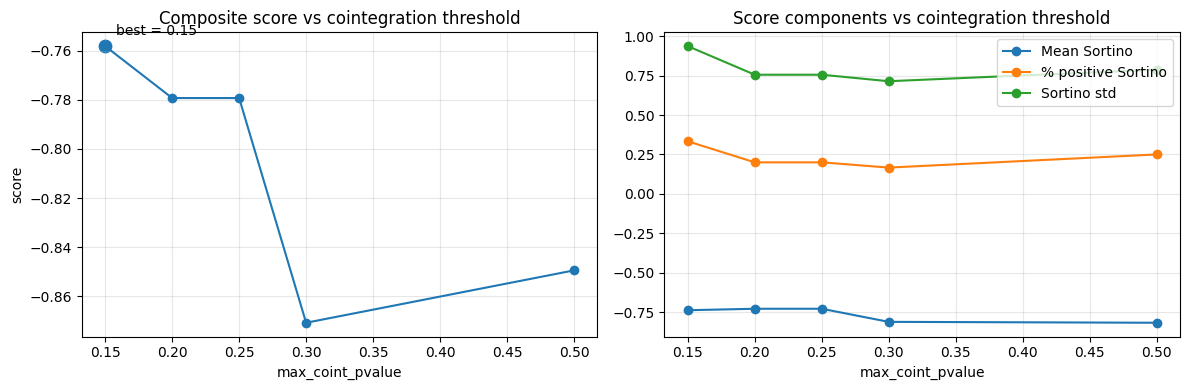

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Composite score
axes[0].plot(
    performance_df["max_coint_pvalue"],
    performance_df["score"],
    marker="o"
)

axes[0].set_title("Composite score vs cointegration threshold")
axes[0].set_xlabel("max_coint_pvalue")
axes[0].set_ylabel("score")
axes[0].grid(True, alpha=0.3)

# Highlight best threshold
best_idx = performance_df["score"].idxmax()
best_x = performance_df.loc[best_idx, "max_coint_pvalue"]
best_y = performance_df.loc[best_idx, "score"]

axes[0].scatter(best_x, best_y, s=80)
axes[0].annotate(
    f"best = {best_x:.2f}",
    xy=(best_x, best_y),
    xytext=(8, 8),
    textcoords="offset points"
)

# 2) Components

axes[1].plot(
    performance_df["max_coint_pvalue"],
    performance_df["mean_sortino"],
    marker="o",
    label="Mean Sortino"
)

axes[1].plot(
    performance_df["max_coint_pvalue"],
    performance_df["pct_positive"],
    marker="o",
    label="% positive Sortino"
)

axes[1].plot(
    performance_df["max_coint_pvalue"],
    performance_df["std_sortino"],
    marker="o",
    label="Sortino std"
)

axes[1].set_title("Score components vs cointegration threshold")
axes[1].set_xlabel("max_coint_pvalue")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
max_coint_pvalue=0.15

Next, we're going to do the same with min_corr_returns

In [13]:
tested_corr_thresholds = [0.00, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]

corr_results = []

for corr_threshold in tested_corr_thresholds:
    sortinos = []

    for asset_name in full_universe.columns:
        try:
            asset_series = full_universe[asset_name]

            diag = evaluate_pair_candidate(
                asset_series,
                coal,
                asset_name,
                "COAL",
                min_obs=200,
                max_coint_pvalue=0.15,
                min_corr_returns=corr_threshold
            )

            if not diag["eligible"]:
                continue

            pair_log = prepare_pair_series(
                asset_series,
                coal,
                asset_name,
                "COAL"
            )

            result = analyze_pairs_trading(
                pair_log,
                threshold_value=1.0,
                verbose=False
            )

            if np.isfinite(result["oos_sortino"]):
                sortinos.append(result["oos_sortino"])

        except Exception:
            continue

    sortinos = np.array(sortinos)
    n = len(sortinos)

    mean_sortino = np.mean(sortinos) if n > 0 else np.nan
    pct_positive = np.mean(sortinos > 0) if n > 0 else np.nan
    std_sortino = np.std(sortinos) if n > 0 else np.nan
    max_sortino = np.max(sortinos) if n > 0 else np.nan

    score = (
        mean_sortino
        + 0.5 * pct_positive
        - 0.2 * std_sortino
    ) if n > 0 else np.nan

    corr_results.append({
        "min_corr_returns": corr_threshold,
        "n_pairs": n,
        "mean_sortino": mean_sortino,
        "pct_positive": pct_positive,
        "std_sortino": std_sortino,
        "max_sortino": max_sortino,
        "score": score
    })

corr_df = pd.DataFrame(corr_results)
corr_df

,min_corr_returns,n_pairs,mean_sortino,pct_positive,std_sortino,max_sortino,score
0,0.00,3,-0.737521,0.333333,0.936489,0.075835,-0.758152
1,0.03,3,-0.737521,0.333333,0.936489,0.075835,-0.758152
2,0.05,3,-0.737521,0.333333,0.936489,0.075835,-0.758152
3,0.07,2,-0.081591,0.500000,0.157426,0.075835,0.136924
4,0.10,1,-0.239017,0.000000,0.000000,-0.239017,-0.239017
5,0.15,0,NaN,NaN,NaN,NaN,NaN
6,0.20,0,NaN,NaN,NaN,NaN,NaN


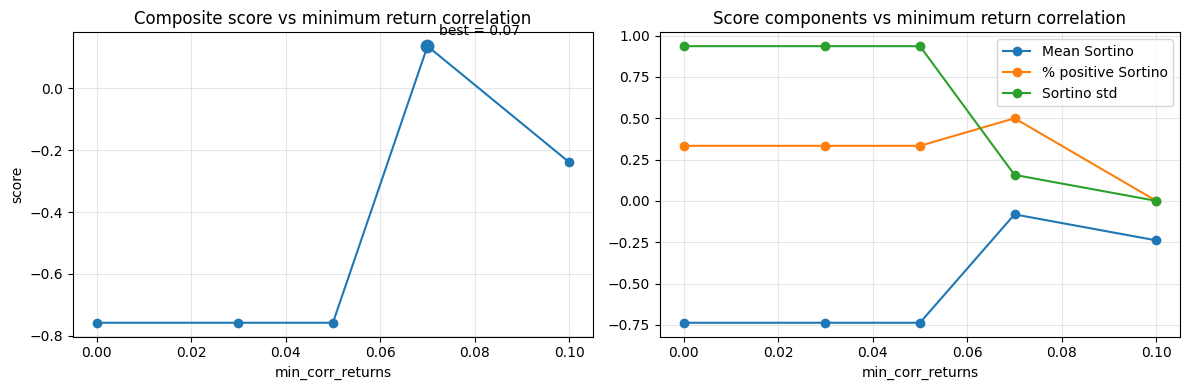

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Composite score
axes[0].plot(
    corr_df["min_corr_returns"],
    corr_df["score"],
    marker="o"
)
axes[0].set_title("Composite score vs minimum return correlation")
axes[0].set_xlabel("min_corr_returns")
axes[0].set_ylabel("score")
axes[0].grid(True, alpha=0.3)

best_idx = corr_df["score"].idxmax()
best_x = corr_df.loc[best_idx, "min_corr_returns"]
best_y = corr_df.loc[best_idx, "score"]

axes[0].scatter(best_x, best_y, s=80)
axes[0].annotate(
    f"best = {best_x:.2f}",
    xy=(best_x, best_y),
    xytext=(8, 8),
    textcoords="offset points"
)

# 2) Main components
axes[1].plot(
    corr_df["min_corr_returns"],
    corr_df["mean_sortino"],
    marker="o",
    label="Mean Sortino"
)
axes[1].plot(
    corr_df["min_corr_returns"],
    corr_df["pct_positive"],
    marker="o",
    label="% positive Sortino"
)
axes[1].plot(
    corr_df["min_corr_returns"],
    corr_df["std_sortino"],
    marker="o",
    label="Sortino std"
)

axes[1].set_title("Score components vs minimum return correlation")
axes[1].set_xlabel("min_corr_returns")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
min_corr_returns=0.07

## 5. Results across all pairs

We run the strategy on all eligible pairs and compare their performance.

This allows us to identify the most promising candidates.

In [16]:
results_vs_coal = []

for asset_name in full_universe.columns:
    try:
        asset_series = full_universe[asset_name]

        # 1) Prepare aligned log-price series
        pair_log = prepare_pair_series(
            asset_series,
            coal,
            asset_name,
            "COAL"
        )

        # 2) Diagnostics
        diag = evaluate_pair_candidate(
            asset_series,
            coal,
            asset_name,
            "COAL",
            min_obs=200,
            max_coint_pvalue=0.15,
            min_corr_returns=0.07
        )

        # 3) Strategy
        result = analyze_pairs_trading(
            pair_log,
            split_ratio=0.75,
            threshold_value=0.7,
            transaction_cost=0.002,
            trailing_stop_factor=0.025,
            min_holding_period=5,
            vol_lookback=30,
            vol_threshold=1.5,
            risk_free_daily=0.0,
            verbose=False
        )

        results_vs_coal.append({
            "asset": asset_name,
            "asset_type": "stock" if asset_name in stock_prices.columns else "sector",
            "n_obs": diag["n_obs"],
            "corr_levels": diag["corr_levels"],
            "corr_returns": diag["corr_returns"],
            "coint_pvalue": diag["coint_pvalue"],
            "eligible": diag["eligible"],

            "best_lookback": result["best_lookback"],
            "oos_sharpe": result["oos_sharpe"],
            "oos_sortino": result["oos_sortino"],
            "oos_cumret": result["oos_cumret"],
            "stop_loss_hits": result["stop_loss_hits"]
        })

    except Exception as e:
        results_vs_coal.append({
            "asset": asset_name,
            "asset_type": "stock" if asset_name in stock_prices.columns else "sector",
            "n_obs": np.nan,
            "corr_levels": np.nan,
            "corr_returns": np.nan,
            "coint_pvalue": np.nan,
            "eligible": False,
            "best_lookback": np.nan,
            "oos_sharpe": np.nan,
            "oos_sortino": np.nan,
            "oos_cumret": np.nan,
            "stop_loss_hits": np.nan,
            "error": str(e)
        })

results_vs_coal_df = pd.DataFrame(results_vs_coal)
results_vs_coal_df

,asset,asset_type,n_obs,corr_levels,corr_returns,coint_pvalue,eligible,best_lookback,oos_sharpe,oos_sortino,oos_cumret,stop_loss_hits
0,AMR,stock,1255,0.052672,0.076036,0.163379,False,5,-0.746201,-0.844432,-0.408899,154
1,ARLP,stock,1255,0.016824,0.112019,0.121857,True,15,-0.462889,-0.619692,-0.126291,125
2,BHP,stock,1255,0.079343,0.053031,0.147508,False,265,-2.423033,-2.736490,-0.505021,104
3,BTU,stock,1255,0.314725,0.112081,0.151836,False,135,-1.044286,-1.382155,-0.554692,122
4,HNRG,stock,1255,-0.281933,0.060649,0.456242,False,90,0.941115,1.148268,0.575718,130
5,NC,stock,1255,0.379319,0.050644,0.297250,False,310,-1.248588,-1.553453,-0.504928,96
6,NRP,stock,1255,-0.349842,0.074494,0.143438,True,10,0.543284,0.855530,0.115889,128
7,RIO,stock,1255,-0.150037,0.047114,0.416246,False,215,-1.441213,-1.848379,-0.346404,114
8,TECK,stock,1255,-0.094876,0.029067,0.230754,False,315,-0.840824,-0.825543,-0.332922,83
9,WHC,stock,1255,0.160982,0.077185,0.587747,False,5,-0.975956,-1.220785,-0.335749,142


In [17]:
results_vs_coal_df[results_vs_coal_df["eligible"] == True].sort_values("oos_sortino", ascending=False)

,asset,asset_type,n_obs,corr_levels,corr_returns,coint_pvalue,eligible,best_lookback,oos_sharpe,oos_sortino,oos_cumret,stop_loss_hits
6,NRP,stock,1255,-0.349842,0.074494,0.143438,True,10,0.543284,0.855530,0.115889,128
1,ARLP,stock,1255,0.016824,0.112019,0.121857,True,15,-0.462889,-0.619692,-0.126291,125


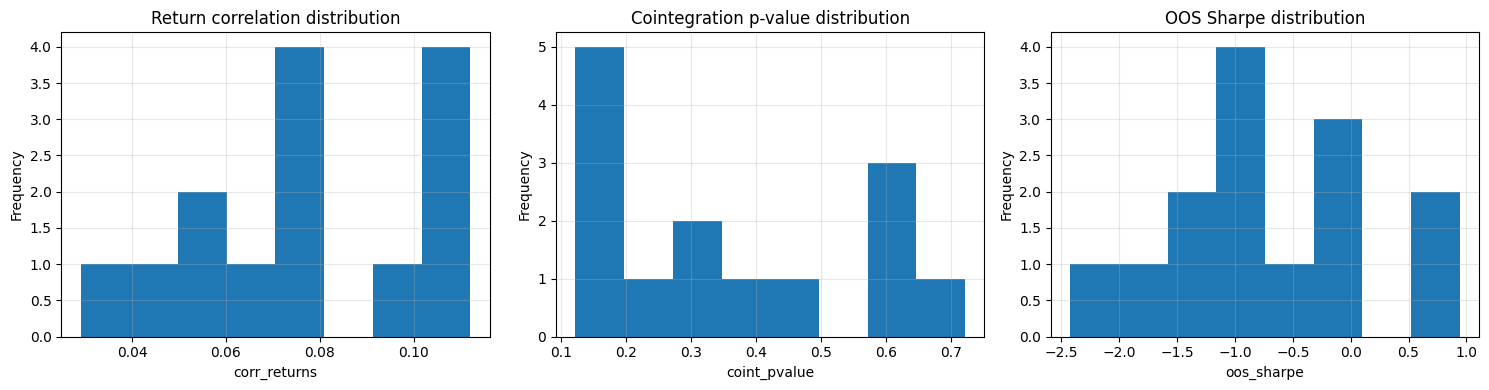

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# corr_returns
axes[0].hist(results_vs_coal_df["corr_returns"].dropna(), bins=8)
axes[0].set_title("Return correlation distribution")
axes[0].set_xlabel("corr_returns")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)

# cointegration p-value
axes[1].hist(results_vs_coal_df["coint_pvalue"].dropna(), bins=8)
axes[1].set_title("Cointegration p-value distribution")
axes[1].set_xlabel("coint_pvalue")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)

# Sharpe
axes[2].hist(results_vs_coal_df["oos_sharpe"].dropna(), bins=8)
axes[2].set_title("OOS Sharpe distribution")
axes[2].set_xlabel("oos_sharpe")
axes[2].set_ylabel("Frequency")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

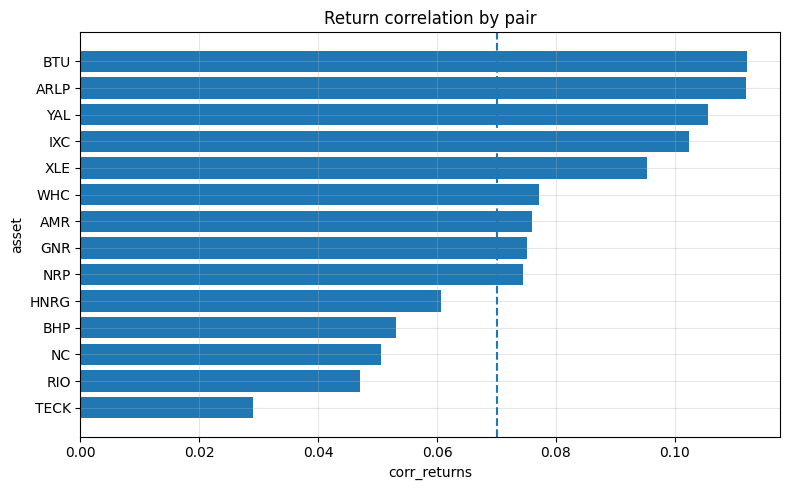

In [19]:
df_sorted = results_vs_coal_df.sort_values("corr_returns")

plt.figure(figsize=(8,5))
plt.barh(df_sorted["asset"], df_sorted["corr_returns"])

plt.axvline(0.07, linestyle="--")

plt.title("Return correlation by pair")
plt.xlabel("corr_returns")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

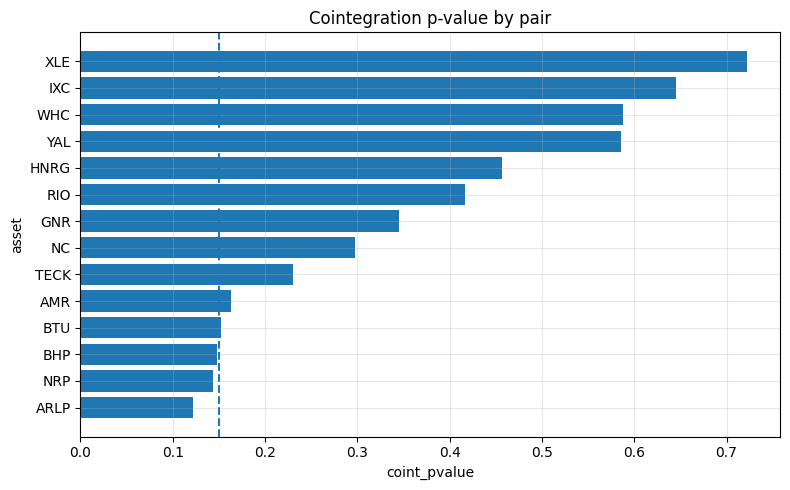

In [20]:
df_sorted = results_vs_coal_df.sort_values("coint_pvalue")

plt.figure(figsize=(8,5))
plt.barh(df_sorted["asset"], df_sorted["coint_pvalue"])

plt.axvline(0.15, linestyle="--")

plt.title("Cointegration p-value by pair")
plt.xlabel("coint_pvalue")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

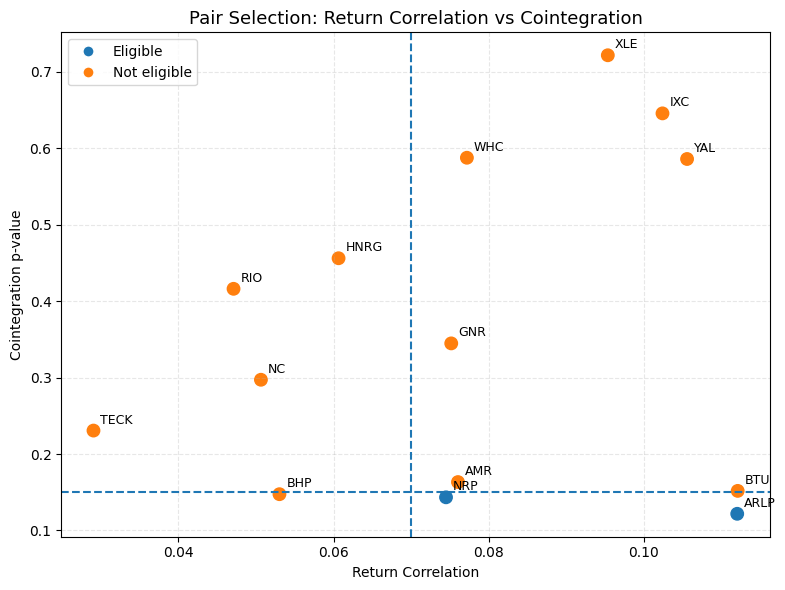

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

# color defined by eligibility
colors = results_vs_coal_df["eligible"].map({True: "tab:blue", False: "tab:orange"})

# scatter
ax.scatter(
    results_vs_coal_df["corr_returns"],
    results_vs_coal_df["coint_pvalue"],
    c=colors,
    s=80
)

# Treshold line
ax.axvline(0.07, linestyle="--")
ax.axhline(0.15, linestyle="--")

# Annotations
for i, row in results_vs_coal_df.iterrows():
    ax.annotate(
        row["asset"],
        (row["corr_returns"], row["coint_pvalue"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

ax.set_title("Pair Selection: Return Correlation vs Cointegration", fontsize=13)
ax.set_xlabel("Return Correlation")
ax.set_ylabel("Cointegration p-value")

# Transparent Grid
ax.grid(True, linestyle="--", alpha=0.3)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Eligible',
           markerfacecolor='tab:blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Not eligible',
           markerfacecolor='tab:orange', markersize=8)
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## 6. Focus on best pairs

We analyze in detail the top-performing pairs using:
- returns distribution
- drawdowns
- risk metrics
- stability over time

#### A. Global performance overview

We compare all pairs based on performance metrics (Sharpe, Sortino, returns).

This gives a first ranking of the candidates.

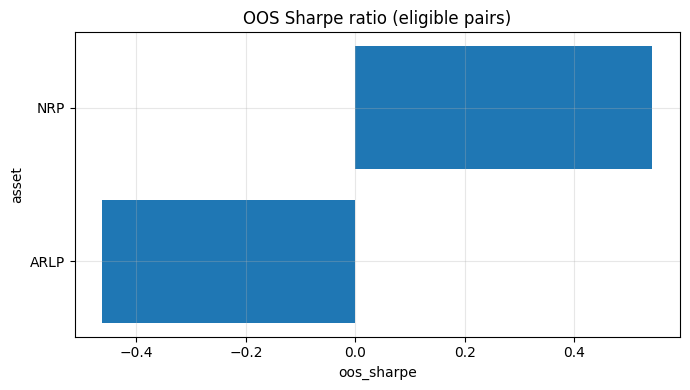

In [22]:
df_valid = results_vs_coal_df[results_vs_coal_df["eligible"] == True]
df_sorted = df_valid.sort_values("oos_sharpe")

plt.figure(figsize=(7,4))
plt.barh(df_sorted["asset"], df_sorted["oos_sharpe"])

plt.title("OOS Sharpe ratio (eligible pairs)")
plt.xlabel("oos_sharpe")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

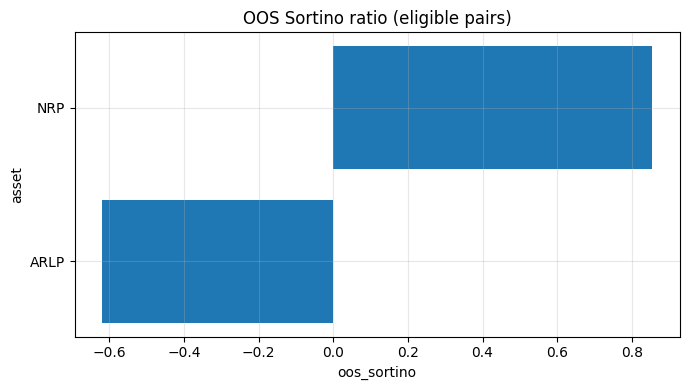

In [23]:
df_valid = results_vs_coal_df[results_vs_coal_df["eligible"] == True]
df_sorted = df_valid.sort_values("oos_sortino")

plt.figure(figsize=(7,4))
plt.barh(df_sorted["asset"], df_sorted["oos_sortino"])

plt.title("OOS Sortino ratio (eligible pairs)")
plt.xlabel("oos_sortino")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
df_valid = results_vs_coal_df[results_vs_coal_df["eligible"] == True].copy()

df_valid["diff_sortino_sharpe"] = (
    df_valid["oos_sortino"] - df_valid["oos_sharpe"]
)

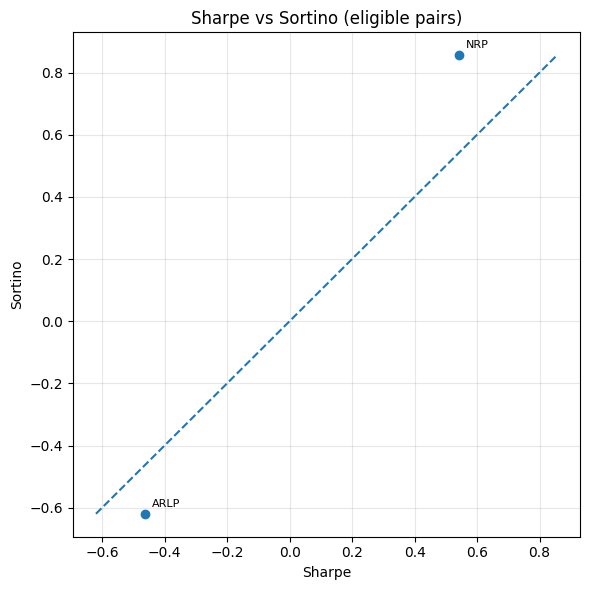

In [25]:
plt.figure(figsize=(6,6))

plt.scatter(
    df_valid["oos_sharpe"],
    df_valid["oos_sortino"]
)

# Line
min_val = min(df_valid["oos_sharpe"].min(), df_valid["oos_sortino"].min())
max_val = max(df_valid["oos_sharpe"].max(), df_valid["oos_sortino"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

# Annotations for points
for _, row in df_valid.iterrows():
    plt.annotate(
        row["asset"],
        (row["oos_sharpe"], row["oos_sortino"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Sharpe")
plt.ylabel("Sortino")
plt.title("Sharpe vs Sortino (eligible pairs)")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NRP vs Coal shows positive Sharpe (~0.55) and Sortino (~0.85), indicating profitable performance with limited downside risk. In contrast, ARLP vs Coal has negative Sharpe (almost -0.45) and Sortino (almost -0.60), meaning returns are both weak and dominated by losses.

This gap is clearly reflected in the graphs: NRP appears stable and consistent, while ARLP looks unreliable and not economically viable.


=== ARLP vs COAL ===
Skewness: 0.884
Kurtosis: 10.910 (leptokurtic)


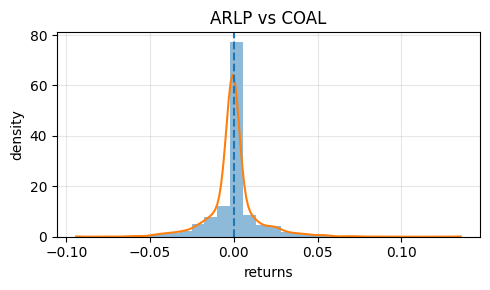


=== NRP vs COAL ===
Skewness: 0.165
Kurtosis: 11.740 (leptokurtic)


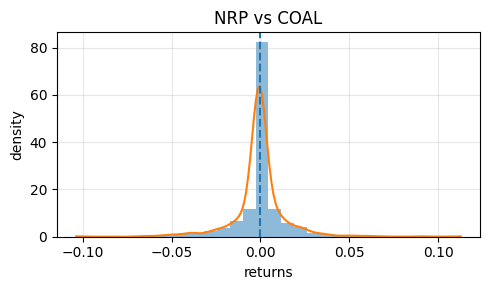

In [26]:
for asset_name in df_valid["asset"]:
    
    # récupérer la bonne série
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]
    
    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )
    
    result = analyze_pairs_trading(
        pair_log,
        verbose=False
    )
    
    returns = result["returns"].dropna()
    
    # Stats
    skewness = skew(returns)
    kurt = kurtosis(returns)  
    
    if kurt > 0:
        kurt_label = "leptokurtic"
    elif kurt < 0:
        kurt_label = "platykurtic"
    else:
        kurt_label = "mesokurtic"
    
    print(f"\n=== {asset_name} vs COAL ===")
    print(f"Skewness: {skewness:.3f}")
    print(f"Kurtosis: {kurt:.3f} ({kurt_label})")

    plt.figure(figsize=(5,3))
    plt.hist(returns, bins=30, density=True, alpha=0.5)
    
    # KDE
    x = np.linspace(returns.min(), returns.max(), 200)
    bandwidth = returns.std() * (len(returns) ** (-1/5))
    kde = np.zeros_like(x)
    
    for r in returns:
        kde += np.exp(-0.5 * ((x - r) / bandwidth) ** 2)
    
    kde /= (len(returns) * bandwidth * np.sqrt(2 * np.pi))
    
    plt.plot(x, kde)
    
    plt.axvline(0, linestyle="--")
    
    plt.title(f"{asset_name} vs COAL")
    plt.xlabel("returns")
    plt.ylabel("density")
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Both pairs exhibit very high kurtosis (>10), indicating fat tails and frequent extreme moves.  
NRP vs Coal has near-zero skewness (almost 0.16), suggesting a balanced distribution of gains and losses, while ARLP vs Coal shows strong positive skewness (almost 0.88), pointing to an asymmetric profile with occasional large gains but more frequent losses.

This is consistent with the graphs: NRP appears more stable and well-behaved, whereas ARLP shows a less reliable and structurally imbalanced return profile.

#### B. Extreme events analysis

We analyze tail risks and extreme losses using:
- drawdowns
- tail risk metrics (VaR, CVaR)

This helps assess downside risk.

In [27]:
# Drawdown: measures the decline from a historical peak in portfolio value.
def compute_drawdown_series(returns: pd.Series) -> pd.Series:
    r = pd.Series(returns).fillna(0)
    equity_curve = (1 + r).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown


# Maximum drawdown is the worst peak-to-trough loss.
def compute_max_drawdown(returns: pd.Series) -> float:
    dd = compute_drawdown_series(returns)
    return float(dd.min()) if not dd.empty else np.nan


# Value-at-Risk (VaR) is a quantile of the return distribution.
def compute_var(returns: pd.Series, alpha: float = 0.05) -> float:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return np.nan
    return float(np.quantile(r, alpha))


# Conditional VaR (CVaR) is the average loss beyond VaR (it help us to capture what's beyond it)
def compute_cvar(returns: pd.Series, alpha: float = 0.05) -> float:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return np.nan

    var_alpha = np.quantile(r, alpha)
    tail_losses = r[r <= var_alpha]

    if tail_losses.empty:
        return np.nan

    return float(tail_losses.mean())


# EVT-style statistics focus on extreme losses below a quantile threshold.
def compute_evt_stats(returns: pd.Series, alpha: float = 0.05) -> dict:
    r = pd.Series(returns).dropna()
    r = r[np.isfinite(r)]
    if r.empty:
        return {
            "evt_threshold": np.nan,
            "n_extreme_losses": np.nan,
            "pct_extreme_losses": np.nan,
            "mean_extreme_loss": np.nan,
            "worst_loss": np.nan
        }

    threshold = np.quantile(r, alpha)
    extreme_losses = r[r <= threshold]

    return {
        "evt_threshold": float(threshold),
        "n_extreme_losses": int(len(extreme_losses)),
        "pct_extreme_losses": float(len(extreme_losses) / len(r)),
        "mean_extreme_loss": float(extreme_losses.mean()) if len(extreme_losses) > 0 else np.nan,
        "worst_loss": float(extreme_losses.min()) if len(extreme_losses) > 0 else np.nan
    }

def compute_calmar_ratio(returns: pd.Series) -> float:
    r = pd.Series(returns).dropna()
    if r.empty:
        return np.nan

    annual_return = r.mean() * TRADING_DAYS_PER_YEAR
    max_dd = compute_max_drawdown(r)

    if max_dd == 0 or np.isnan(max_dd):
        return np.nan

    return float(annual_return / abs(max_dd))

In [28]:
extreme_risk_results = []

for asset_name in df_valid["asset"]:
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]

    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )

    result = analyze_pairs_trading(
        pair_log,
        split_ratio=0.75,
        threshold_value=0.7,
        transaction_cost=0.002,
        trailing_stop_factor=0.025,
        min_holding_period=5,
        vol_lookback=30,
        vol_threshold=1.5,
        risk_free_daily=0.0,
        verbose=False
    )

    returns = result["returns"].iloc[result["train_index"]:]  # OOS only

    evt_stats = compute_evt_stats(returns, alpha=0.05)

    extreme_risk_results.append({
        "asset": asset_name,
        "max_drawdown": compute_max_drawdown(returns),
        "var_95": compute_var(returns, alpha=0.05),
        "cvar_95": compute_cvar(returns, alpha=0.05),
        "calmar_ratio": compute_calmar_ratio(returns),
        **evt_stats
    })

extreme_risk_df = pd.DataFrame(extreme_risk_results)
extreme_risk_df

,asset,max_drawdown,var_95,cvar_95,calmar_ratio,evt_threshold,n_extreme_losses,pct_extreme_losses,mean_extreme_loss,worst_loss
0,ARLP,-0.164406,-0.019696,-0.027897,-0.545475,-0.019696,16,0.050955,-0.027897,-0.045204
1,NRP,-0.256970,-0.014948,-0.023312,0.415657,-0.014948,16,0.050955,-0.023312,-0.044755


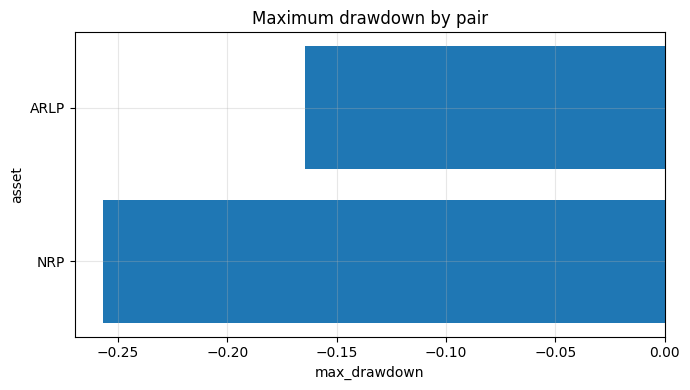

In [29]:
df_dd = extreme_risk_df.sort_values("max_drawdown")

plt.figure(figsize=(7, 4))
plt.barh(df_dd["asset"], df_dd["max_drawdown"])

plt.title("Maximum drawdown by pair")
plt.xlabel("max_drawdown")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

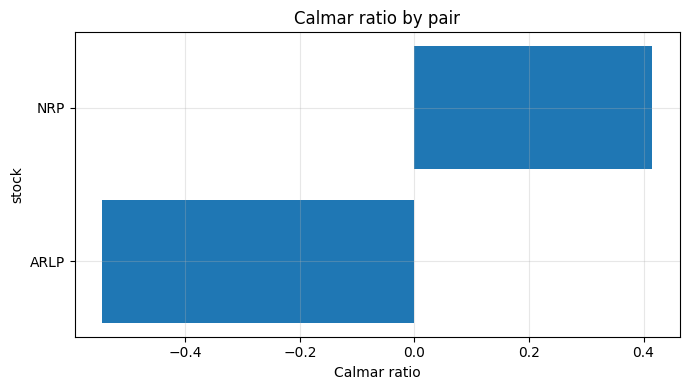

In [31]:
df_calmar = extreme_risk_df.sort_values("calmar_ratio")

plt.figure(figsize=(7,4))
plt.barh(df_calmar["asset"], df_calmar["calmar_ratio"])

plt.title("Calmar ratio by pair")
plt.xlabel("Calmar ratio")
plt.ylabel("stock")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

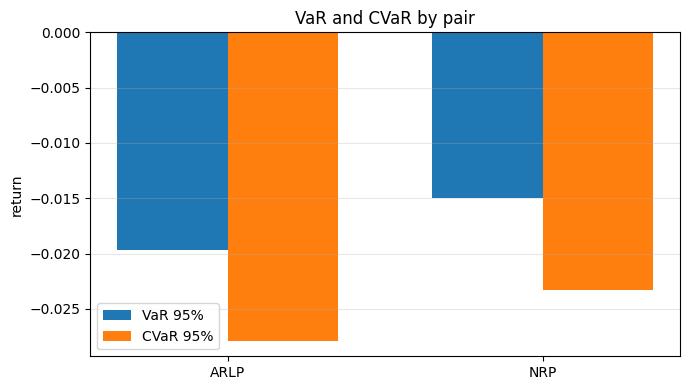

In [ ]:
x = np.arange(len(extreme_risk_df))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, extreme_risk_df["var_95"], width, label="VaR 95%")
plt.bar(x + width/2, extreme_risk_df["cvar_95"], width, label="CVaR 95%")

plt.xticks(x, extreme_risk_df["asset"])
plt.title("VaR and CVaR by pair")
plt.ylabel("return")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

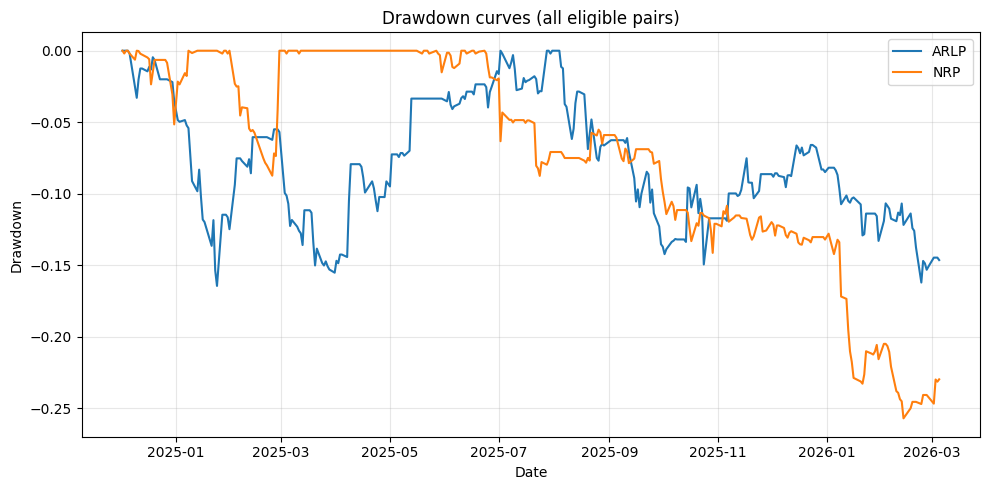

In [ ]:
plt.figure(figsize=(10,5))

for asset_name in df_valid["asset"]:
    
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]
    
    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )

    result = analyze_pairs_trading(
        pair_log,
        split_ratio=0.75,
        threshold_value=0.7,
        transaction_cost=0.002,
        trailing_stop_factor=0.025,
        min_holding_period=5,
        vol_lookback=30,
        vol_threshold=1.5,
        risk_free_daily=0.0,
        verbose=False
    )

    oos_returns = result["returns"].iloc[result["train_index"]:]
    drawdown = compute_drawdown_series(oos_returns)

    plt.plot(drawdown.index, drawdown.values, label=asset_name)

plt.title("Drawdown curves (all eligible pairs)")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NRP vs Coal shows a larger maximum drawdown (almost -25%), mainly driven by a late stress episode, but its tail risk remains relatively controlled with lower VaR (almost -1.5%) and CVaR (almost -2.3%).
In contrast, ARLP vs Coal has a smaller drawdown (almost -16%) but significantly higher VaR and CVaR, indicating more frequent and severe losses. This is consistent with the drawdown curves: ARLP suffers from repeated and persistent drawdowns, while NRP stays stable for most of the period aside from a single sharp decline.

This difference in risk profile is also reflected in the Calmar ratio, which penalizes ARLP due to its persistent drawdowns despite a lower maximum drawdown, while NRP benefits from stronger overall return dynamics.

As highlighted by Palazzi's papper, robustness to extreme events is key: NRP captures a meaningful signal but is sensitive to regime shifts, whereas ARLP appears structurally unstable.

#### C. Stability analysis

We evaluate the stability of the strategies over time using:
- rolling metrics
- equity curves
- hit ratio

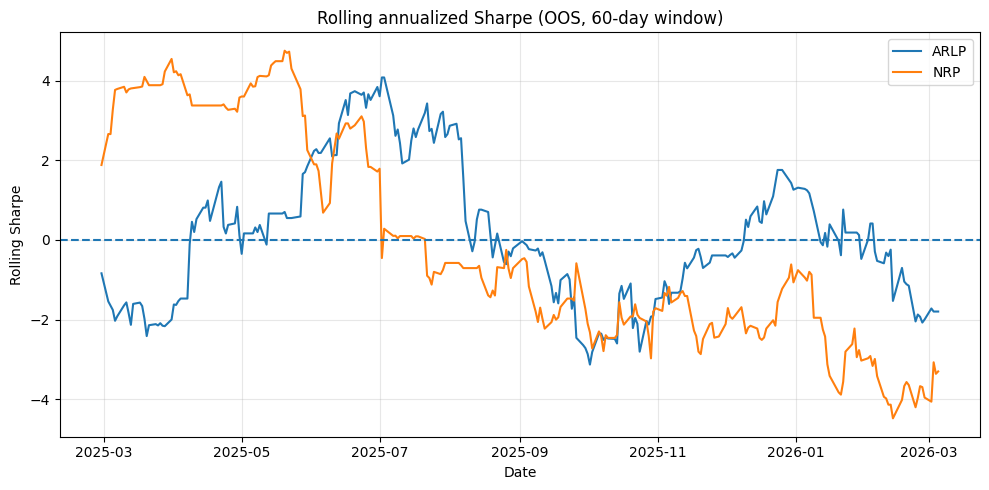

In [ ]:
def rolling_annualized_sharpe(returns: pd.Series, window: int = 60, rf: float = 0.0) -> pd.Series:
    r = pd.Series(returns).copy()

    values = []
    index = []

    for i in range(window, len(r) + 1):
        window_returns = r.iloc[i - window:i]
        values.append(_annualized_sharpe(window_returns, rf=rf))
        index.append(r.index[i - 1])

    return pd.Series(values, index=index)


plt.figure(figsize=(10, 5))

for asset_name in df_valid["asset"]:
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]

    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )

    result = analyze_pairs_trading(
        pair_log,
        split_ratio=0.75,
        threshold_value=0.7,
        transaction_cost=0.002,
        trailing_stop_factor=0.025,
        min_holding_period=5,
        vol_lookback=30,
        vol_threshold=1.5,
        risk_free_daily=0.0,
        verbose=False
    )

    oos_returns = result["returns"].iloc[result["train_index"]:]
    rolling_sharpe = rolling_annualized_sharpe(oos_returns, window=60, rf=0.0)

    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=asset_name)

plt.axhline(0, linestyle="--")
plt.title("Rolling annualized Sharpe (OOS, 60-day window)")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

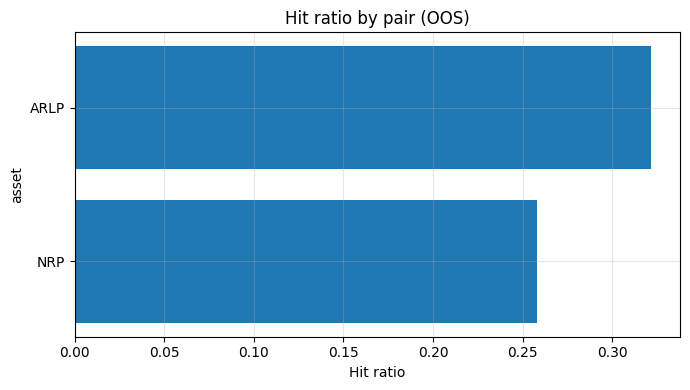

In [ ]:
hit_ratio_results = []

for asset_name in df_valid["asset"]:
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]

    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )

    result = analyze_pairs_trading(
        pair_log,
        split_ratio=0.75,
        threshold_value=0.7,
        transaction_cost=0.002,
        trailing_stop_factor=0.025,
        min_holding_period=5,
        vol_lookback=30,
        vol_threshold=1.5,
        risk_free_daily=0.0,
        verbose=False
    )

    oos_returns = result["returns"].iloc[result["train_index"]:].dropna()

    hit_ratio = np.mean(oos_returns > 0) if len(oos_returns) > 0 else np.nan

    hit_ratio_results.append({
        "asset": asset_name,
        "hit_ratio": hit_ratio
    })

hit_ratio_df = pd.DataFrame(hit_ratio_results).sort_values("hit_ratio")

plt.figure(figsize=(7, 4))
plt.barh(hit_ratio_df["asset"], hit_ratio_df["hit_ratio"])

plt.title("Hit ratio by pair (OOS)")
plt.xlabel("Hit ratio")
plt.ylabel("asset")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

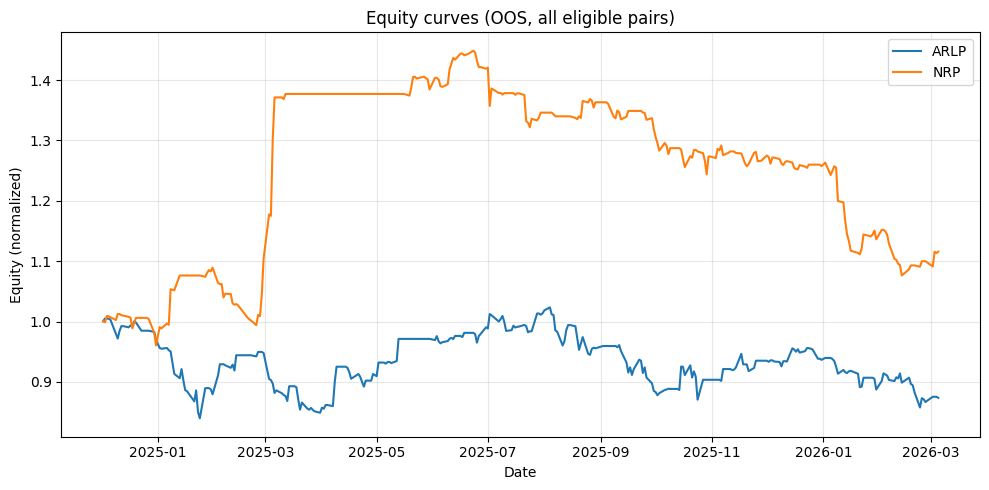

In [ ]:
plt.figure(figsize=(10,5))

for asset_name in df_valid["asset"]:
    
    if asset_name in stock_prices.columns:
        series = stock_prices[asset_name]
    else:
        series = sector_prices[asset_name]
    
    pair_log = prepare_pair_series(
        series,
        coal,
        asset_name,
        "COAL"
    )

    result = analyze_pairs_trading(
        pair_log,
        split_ratio=0.75,
        threshold_value=0.7,
        transaction_cost=0.002,
        trailing_stop_factor=0.025,
        min_holding_period=5,
        vol_lookback=30,
        vol_threshold=1.5,
        risk_free_daily=0.0,
        verbose=False
    )

    oos_returns = result["returns"].iloc[result["train_index"]:]
    equity_curve = (1 + oos_returns.fillna(0)).cumprod()

    plt.plot(equity_curve.index, equity_curve.values, label=asset_name)

plt.title("Equity curves (OOS, all eligible pairs)")
plt.xlabel("Date")
plt.ylabel("Equity (normalized)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NRP vs Coal shows strong performance early on (rolling Sharpe > 3–4), followed by a gradual deterioration that eventually turns negative, pointing to sensitivity to changing market regimes.  
ARLP vs Coal, on the other hand, fluctuates around zero throughout, with no sustained positive performance, confirming the lack of a reliable signal.

The hit ratio reinforces this: ARLP achieves a higher hit ratio (almost 32%) than NRP (almost 26%) but remains unprofitable, suggesting frequent small gains offset by larger losses. This is consistent with the equity curves, where ARLP trends downward while NRP shows initial growth before a drawdown.

As highlighted by Palazzi (2025), out-of-sample robustness is key: NRP captures a valid but regime-dependent signal, whereas ARLP fails to exhibit any stable behavior.

## 7. Conclusion

Based on the analysis across performance, distribution, risk, and stability, the choice of the final pair is clear.

From a performance standpoint, the decision is straightforward. ARLP can be ruled out immediately: both its Sharpe and Sortino ratios are negative, meaning the strategy does not generate excess returns and still takes risk (lol). In practice, this is not tradable (unless the objective is to lose money efficiently..). NRP, on the other hand, delivers positive and economically meaningful results, with a Sharpe around 0.55 and a Sortino around 0.85, reflecting both profitability and controlled downside risk.

Beyond this clear selection, the analysis highlights the structure and limitations of the strategy. The NRP pair, while profitable, shows signs of regime dependency. The rolling Sharpe reveals strong initial performance followed by a gradual deterioration, suggesting sensitivity to changing market conditions. The relatively large maximum drawdown (around -25%) also points to exposure during stress periods, despite otherwise controlled tail risk.

ARLP, although not viable as a standalone strategy, still displays some interesting characteristics. It achieves a higher hit ratio (almost 32% versus almost 26% for NRP), meaning it gets more trades right. However, these gains are offset by larger losses, which explains the negative performance. This suggests a signal that reacts more often, but without proper risk control.

This contrast opens the door to a possible hybrid interpretation. NRP provides a more reliable and economically sound mean-reversion signal, while ARLP may still contain information about short-term dynamics. Using ARLP as a complementary or filtering signal, or leveraging its higher trade frequency in a broader framework, could improve the responsiveness of the strategy.

Overall, NRP is selected as the final pair due to its clear economic superiority, while ARLP serves as a useful benchmark showing that cointegration alone does not guarantee profitability. The analysis also highlights that even the selected pair remains sensitive to regime shifts, leaving room for improvement through more adaptive or multi-signal approaches.